# Estimasi Distribusi Fase Siklus Sel dari Data Flow Cytometry Menggunakan Model Dean-Jett-Fox

Notebook ini adalah artefak eksplorasi fase 2 untuk tugas IF3211. Dataset utama adalah Zenodo 14928071, berisi raw flow cytometry FCS untuk eksperimen cell cycle dengan stain propidium iodide (PI). Analisis di sini bersifat komputasi biologi dan tidak boleh dibaca sebagai klaim klinis.

Alur notebook:

1. Baca metadata sumber dataset dan pastikan file Zenodo tersedia lokal.
2. Baca FCS dan preprocess channel `PI-A` menjadi histogram DNA content.
3. Tampilkan histogram per kondisi (`AI`, `AX`) dan timepoint (0, 24, 48, 72 jam).
4. Fit model Dean-Jett-Fox sederhana: puncak G1 dan G2/M dimodelkan Gaussian, komponen S berada di antara keduanya.
5. Hitung proporsi G1/S/G2-M, residual, SSE, RMSE, dan R-squared.
6. Bandingkan pola estimasi antar kondisi dan timepoint dengan caveat model.


In [1]:
# Setup dasar. Komentar sengaja ditulis dalam Bahasa Indonesia untuk dokumentasi tugas.
from __future__ import annotations

import json
import math
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import least_squares

ROOT = Path.cwd()
SCRIPTS_DIR = ROOT / "scripts"
RAW_DIR = ROOT / "data" / "raw" / "zenodo" / "14928071"
PROCESSED_SUMMARY = ROOT / "data" / "processed" / "zenodo_14928071_histograms_summary.json"
FIT_SUMMARY_CSV = ROOT / "data" / "processed" / "zenodo_14928071_djf_fit_summary.csv"

sys.path.insert(0, str(SCRIPTS_DIR))
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True


## 1. Provenance Dataset

Metadata provenance ditulis di `data/metadata/dataset_sources.md`. File FlowRepository FR-FCM-ZZMY hanya dicatat sebagai dataset sekunder/cadangan karena download raw file membutuhkan login. Notebook ini hanya memakai Zenodo 14928071.

In [2]:
metadata_path = ROOT / "data" / "metadata" / "dataset_sources.md"
print(metadata_path.read_text(encoding="utf-8")[:1600])


# Dataset Sources

| Field | Value |
| --- | --- |
| Last updated | 2026-05-28 |
| Project | Estimasi Distribusi Fase Siklus Sel dari Data Flow Cytometry Menggunakan Model Dean-Jett-Fox |
| Course context | IF3211 Domain-Specific Computation |

## Dataset Utama: Zenodo 14928071

- Nama dataset: Raw Flow Cytometry data files for Figures 2A and 2D of the article: A nonenzymatic dependency on inositol-requiring enzyme 1 controls cancer cell cycle progression and tumor growth
- Record URL: <https://zenodo.org/records/14928071>
- API metadata: <https://zenodo.org/api/records/14928071>
- DOI: `10.5281/zenodo.14928071`
- Tipe data: raw flow cytometry dalam format FCS 3.0
- Konteks eksperimen: data flow cytometry cell cycle; konteks artikel/figure terkait menyebut sel di-stain dengan propidium iodide (PI) dan dianalisis berdasarkan DNA content.
- Lokasi raw data lokal: `data/raw/zenodo/14928071/`
- Lokasi metadata lokal:
  - `data/metadata/zenodo_14928071_download_manifest.json`
  - `data/meta

## 2. Preprocessing FCS Zenodo ke Histogram PI-A

Channel kandidat DNA/PI dari metadata FCS adalah `PI-A` pada parameter P7. Jika ringkasan histogram belum ada, notebook menjalankan ulang preprocessing dari raw FCS Zenodo. Tidak ada jalur data buatan pada pipeline ini.

In [3]:
from preprocess_zenodo_histograms import main as preprocess_main

priority_files = sorted(RAW_DIR.glob("*.fcs"))
if len(priority_files) != 8:
    raise FileNotFoundError(
        f"Ditemukan {len(priority_files)} file FCS di {RAW_DIR}. "
        "Jalankan: python scripts/download_zenodo_14928071.py"
    )

if not PROCESSED_SUMMARY.exists():
    exit_code = preprocess_main()
    if exit_code != 0:
        raise RuntimeError("Preprocessing FCS Zenodo gagal")

items = json.loads(PROCESSED_SUMMARY.read_text(encoding="utf-8"))
summary_rows = [
    {
        "source_file": item["source_file"],
        "condition": item["condition"],
        "timepoint_hours": int(item["timepoint_hours"]),
        "channel": item["channel"],
        "events_total": item["events_total"],
        "events_used": item["events_used"],
        "csv_path": item["csv_path"],
        "range_min": item["histogram_range"][0],
        "range_max": item["histogram_range"][1],
    }
    for item in items
]
summary_df = pd.DataFrame(summary_rows).sort_values(["condition", "timepoint_hours"])
summary_df


,source_file,condition,timepoint_hours,channel,events_total,events_used,csv_path,range_min,range_max
0,Specimen_001_AI_0_001.fcs,AI,0,PI-A,54449,54206,data/processed/zenodo_14928071_histograms/Spec...,41.385563,140809.312500
1,Specimen_001_AI_24_002.fcs,AI,24,PI-A,54432,54279,data/processed/zenodo_14928071_histograms/Spec...,57.411930,149489.000000
2,Specimen_001_AI_48_003.fcs,AI,48,PI-A,59684,59509,data/processed/zenodo_14928071_histograms/Spec...,50.705849,230842.671875
3,Specimen_001_AI_72_004.fcs,AI,72,PI-A,68301,67939,data/processed/zenodo_14928071_histograms/Spec...,24.942532,172122.781250
4,Specimen_001_AX_0_005.fcs,AX,0,PI-A,54472,54214,data/processed/zenodo_14928071_histograms/Spec...,30.574799,142810.125000
5,Specimen_001_AX_24_006.fcs,AX,24,PI-A,54305,54151,data/processed/zenodo_14928071_histograms/Spec...,51.270885,141937.421875
6,Specimen_001_AX_48_007.fcs,AX,48,PI-A,53997,53801,data/processed/zenodo_14928071_histograms/Spec...,51.386150,151043.296875
7,Specimen_001_AX_72_008.fcs,AX,72,PI-A,54606,54454,data/processed/zenodo_14928071_histograms/Spec...,55.382885,169777.687500


## 3. Visualisasi Histogram PI-A

Histogram ini adalah input awal model. Bentuk histogram perlu dinilai bersama residual fit karena file FCS mentah dapat memuat debris, doublet, outlier, atau efek gating yang belum dimodelkan penuh.

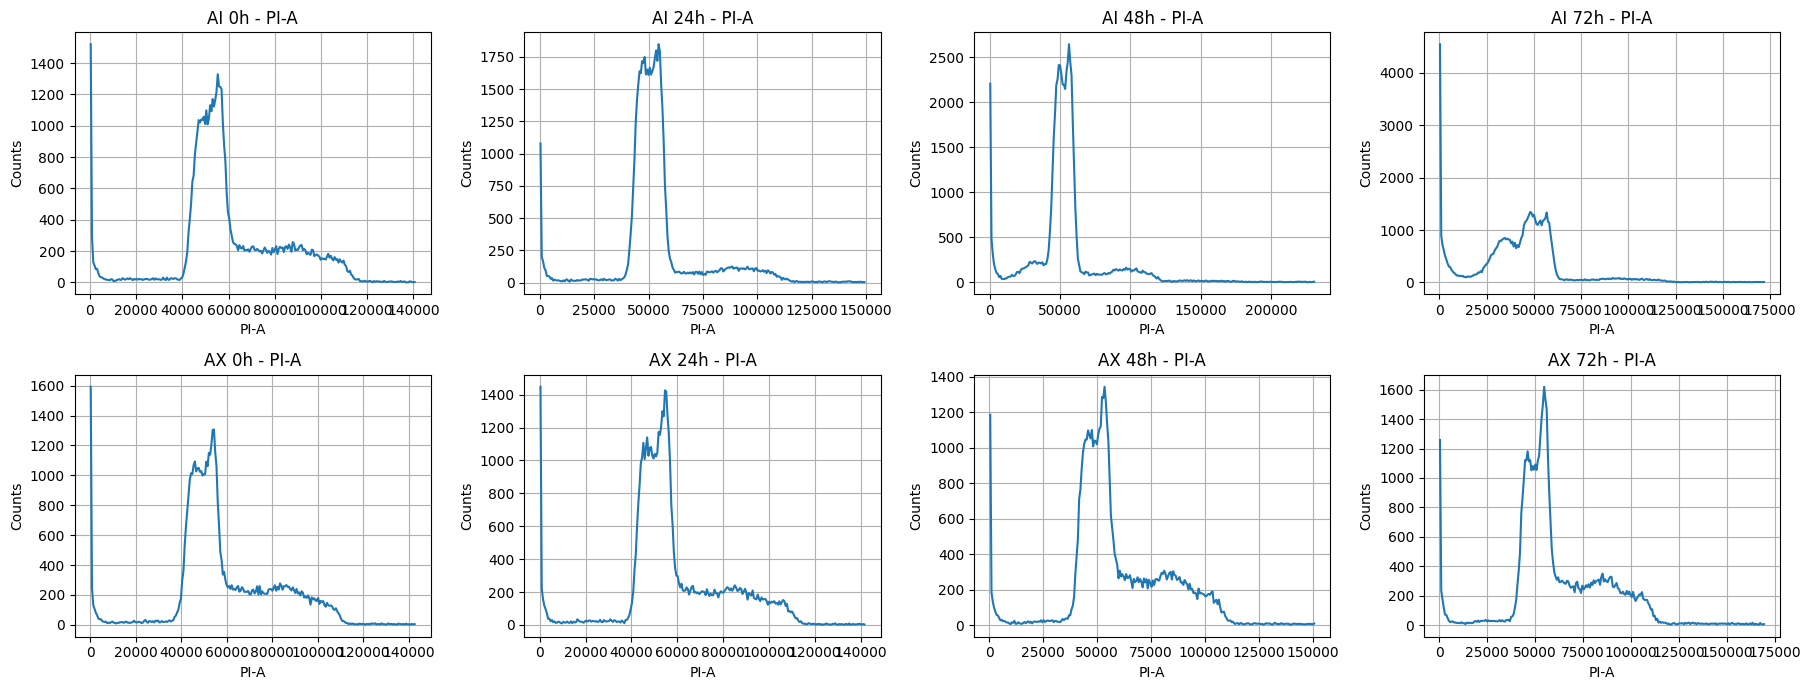

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(18, 7), sharey=False)
axes = axes.ravel()
for ax, item in zip(axes, sorted(items, key=lambda row: (row["condition"], int(row["timepoint_hours"])))):
    bins = np.array(item["bins"], dtype=float)
    counts = np.array(item["counts"], dtype=float)
    ax.plot(bins, counts, color="#1f77b4", linewidth=1.5)
    ax.set_title(f"{item['condition']} {item['timepoint_hours']}h - {item['channel']}")
    ax.set_xlabel("PI-A")
    ax.set_ylabel("Counts")
fig.tight_layout()
plt.show()


## 4. Model Dean-Jett-Fox Sederhana untuk Eksplorasi

Implementasi fase 2 ini memakai bentuk DJF sederhana: G1 dan G2/M sebagai Gaussian, sedangkan fase S dimodelkan sebagai komponen kontinu di antara mean G1 dan G2/M. Implementasi reusable final sebaiknya dipindah ke module `models/` pada fase 3.

In [5]:
def gaussian(x: np.ndarray, amplitude: float, mean: float, sigma: float) -> np.ndarray:
    sigma = max(float(sigma), 1e-6)
    return amplitude * np.exp(-0.5 * ((x - mean) / sigma) ** 2)


def s_phase_component(x: np.ndarray, amplitude: float, g1_mean: float, g2_mean: float) -> np.ndarray:
    # Komponen S dibuat halus di antara G1 dan G2/M agar area fase S bisa dihitung.
    width = max(float(g2_mean - g1_mean), 1e-6)
    t = (x - g1_mean) / width
    inside = (t >= 0.0) & (t <= 1.0)
    shape = np.zeros_like(x, dtype=float)
    shape[inside] = np.sqrt(np.clip(t[inside] * (1.0 - t[inside]), 0.0, None))
    max_shape = shape.max()
    if max_shape > 0:
        shape = shape / max_shape
    return amplitude * shape


def djf_curve(x: np.ndarray, params: np.ndarray) -> tuple[np.ndarray, dict[str, np.ndarray | float]]:
    a1, mu1, sig1, a2, delta, sig2, as_phase, baseline = params
    mu2 = mu1 + delta
    g1 = gaussian(x, a1, mu1, sig1)
    g2_m = gaussian(x, a2, mu2, sig2)
    s_phase = s_phase_component(x, as_phase, mu1, mu2)
    total = g1 + s_phase + g2_m + baseline
    return total, {"g1": g1, "s": s_phase, "g2_m": g2_m, "baseline": baseline, "g1_mean": mu1, "g2_mean": mu2}


def initial_guess(x: np.ndarray, y: np.ndarray) -> np.ndarray:
    y_smooth = pd.Series(y).rolling(window=7, center=True, min_periods=1).mean().to_numpy()
    usable = np.arange(len(x))
    usable = usable[(x > 0.05) & (x < 0.90)]
    peak_idx = usable[np.argmax(y_smooth[usable])] if usable.size else int(np.argmax(y_smooth))
    mu1 = float(x[peak_idx])
    mu2 = min(0.95, max(mu1 + 0.18, mu1 * 1.8))
    baseline = float(np.percentile(y, 5))
    return np.array([
        max(float(y.max() - baseline), 1.0),
        min(max(mu1, 0.08), 0.70),
        0.05,
        max(float((y.max() - baseline) * 0.35), 1.0),
        min(max(mu2 - mu1, 0.12), 0.75),
        0.07,
        max(float((y.max() - baseline) * 0.25), 1.0),
        max(baseline, 0.0),
    ])


def fit_djf_histogram(bins: np.ndarray, counts: np.ndarray) -> dict:
    # Skala x ke 0..1 agar optimisasi stabil lintas file dengan range PI-A berbeda.
    x_raw = bins.astype(float)
    y = counts.astype(float)
    x_min = float(x_raw.min())
    x_max = float(x_raw.max())
    x = (x_raw - x_min) / max(x_max - x_min, 1e-9)

    p0 = initial_guess(x, y)
    lower = np.array([0.0, 0.02, 0.005, 0.0, 0.05, 0.005, 0.0, 0.0])
    upper = np.array([np.inf, 0.85, 0.25, np.inf, 0.90, 0.30, np.inf, np.inf])

    def residual(params: np.ndarray) -> np.ndarray:
        total, _ = djf_curve(x, params)
        return total - y

    result = least_squares(residual, p0, bounds=(lower, upper), max_nfev=5000)
    total, components = djf_curve(x, result.x)
    residuals = y - total

    areas = {
        "g1": float(np.trapezoid(components["g1"], x_raw)),
        "s": float(np.trapezoid(components["s"], x_raw)),
        "g2_m": float(np.trapezoid(components["g2_m"], x_raw)),
    }
    total_area = sum(max(value, 0.0) for value in areas.values())
    phase_percentages = {key: (max(value, 0.0) / total_area * 100.0 if total_area > 0 else np.nan) for key, value in areas.items()}

    sse = float(np.sum(residuals ** 2))
    rmse = float(np.sqrt(np.mean(residuals ** 2)))
    ss_tot = float(np.sum((y - y.mean()) ** 2))
    r_squared = float(1.0 - sse / ss_tot) if ss_tot > 0 else np.nan

    warnings = []
    if not result.success:
        warnings.append("Optimisasi tidak konvergen penuh.")
    if r_squared < 0.80:
        warnings.append("R-squared rendah; interpretasi fase perlu hati-hati.")
    if result.x[4] <= 0.06:
        warnings.append("Jarak G1 dan G2/M berada dekat batas bawah constraint.")

    return {
        "x_scaled": x,
        "bins": x_raw,
        "observed": y,
        "fit_total": total,
        "g1": components["g1"],
        "s": components["s"],
        "g2_m": components["g2_m"],
        "residual": residuals,
        "phase_percentages": phase_percentages,
        "metrics": {"sse": sse, "rmse": rmse, "r_squared": r_squared},
        "parameters": {
            "g1_mean_scaled": float(result.x[1]),
            "g2_mean_scaled": float(result.x[1] + result.x[4]),
            "g1_sigma_scaled": float(result.x[2]),
            "g2_sigma_scaled": float(result.x[5]),
        },
        "warnings": warnings,
    }


## 5. Fit Model, Residual, dan Goodness-of-Fit

Tabel di bawah adalah estimasi awal. Angka fase harus dibaca sebagai output model pada histogram PI-A, bukan label biologis absolut.

In [6]:
fit_results = []
for item in sorted(items, key=lambda row: (row["condition"], int(row["timepoint_hours"]))):
    bins = np.array(item["bins"], dtype=float)
    counts = np.array(item["counts"], dtype=float)
    fit = fit_djf_histogram(bins, counts)
    fit_results.append({"item": item, "fit": fit})

rows = []
for entry in fit_results:
    item = entry["item"]
    fit = entry["fit"]
    rows.append({
        "condition": item["condition"],
        "timepoint_hours": int(item["timepoint_hours"]),
        "source_file": item["source_file"],
        "channel": item["channel"],
        "g1_percent": fit["phase_percentages"]["g1"],
        "s_percent": fit["phase_percentages"]["s"],
        "g2_m_percent": fit["phase_percentages"]["g2_m"],
        "rmse": fit["metrics"]["rmse"],
        "r_squared": fit["metrics"]["r_squared"],
        "warnings": "; ".join(fit["warnings"]),
    })

fit_df = pd.DataFrame(rows).sort_values(["condition", "timepoint_hours"])
FIT_SUMMARY_CSV.parent.mkdir(parents=True, exist_ok=True)
fit_df.to_csv(FIT_SUMMARY_CSV, index=False)
fit_df


,condition,timepoint_hours,source_file,channel,g1_percent,s_percent,g2_m_percent,rmse,r_squared,warnings
0,AI,0,Specimen_001_AI_0_001.fcs,PI-A,66.201845,2.240460e+01,1.139355e+01,113.032647,0.874278,
1,AI,24,Specimen_001_AI_24_002.fcs,PI-A,89.177935,4.945817e-07,1.082206e+01,115.249212,0.936929,
2,AI,48,Specimen_001_AI_48_003.fcs,PI-A,93.450064,1.730550e-06,6.549934e+00,178.488323,0.896694,
3,AI,72,Specimen_001_AI_72_004.fcs,PI-A,96.679143,3.320857e+00,2.485717e-07,315.850925,0.524899,R-squared rendah; interpretasi fase perlu hati...
4,AX,0,Specimen_001_AX_0_005.fcs,PI-A,63.997184,2.186481e+01,1.413800e+01,120.003789,0.856215,
5,AX,24,Specimen_001_AX_24_006.fcs,PI-A,69.775265,1.534847e+01,1.487626e+01,120.541020,0.868911,
6,AX,48,Specimen_001_AX_48_007.fcs,PI-A,62.141130,2.064308e+01,1.721579e+01,97.480382,0.903023,
7,AX,72,Specimen_001_AX_72_008.fcs,PI-A,62.739937,1.867903e+01,1.858103e+01,114.403291,0.885139,


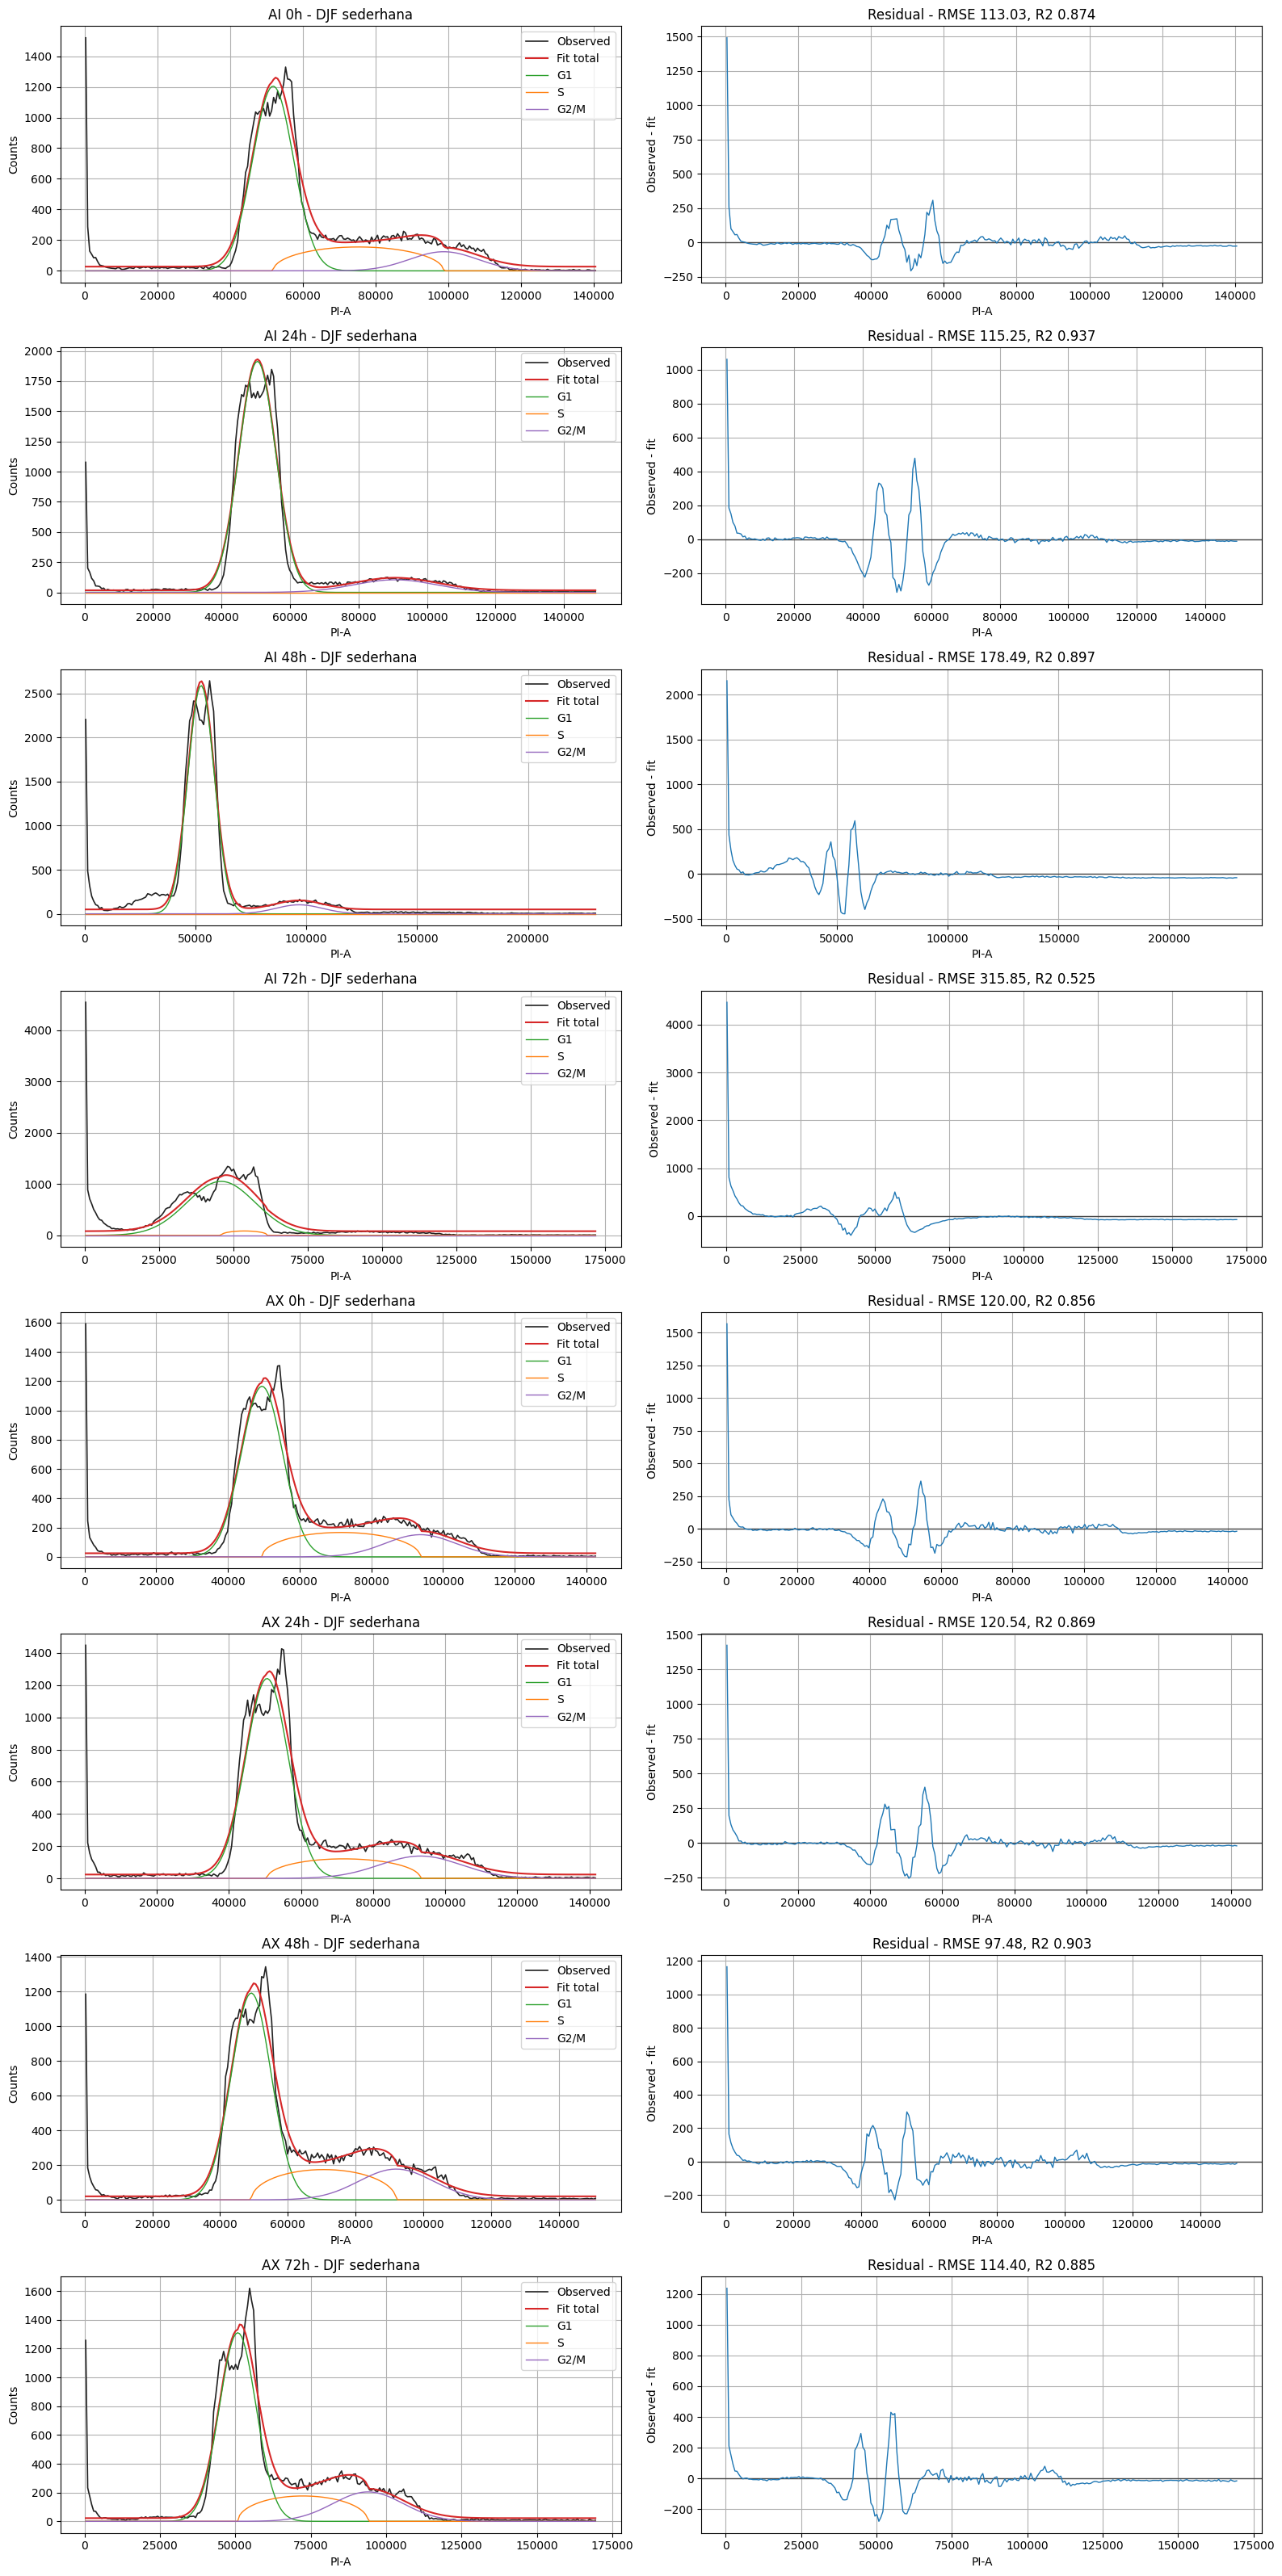

In [7]:
# Plot fit dan residual untuk semua file prioritas.
fig, axes = plt.subplots(len(fit_results), 2, figsize=(16, 4 * len(fit_results)))
for row_idx, entry in enumerate(fit_results):
    item = entry["item"]
    fit = entry["fit"]
    ax_fit = axes[row_idx, 0]
    ax_res = axes[row_idx, 1]

    ax_fit.plot(fit["bins"], fit["observed"], label="Observed", color="#222222", linewidth=1.2)
    ax_fit.plot(fit["bins"], fit["fit_total"], label="Fit total", color="#d62728", linewidth=1.5)
    ax_fit.plot(fit["bins"], fit["g1"], label="G1", color="#2ca02c", linewidth=1.0)
    ax_fit.plot(fit["bins"], fit["s"], label="S", color="#ff7f0e", linewidth=1.0)
    ax_fit.plot(fit["bins"], fit["g2_m"], label="G2/M", color="#9467bd", linewidth=1.0)
    ax_fit.set_title(f"{item['condition']} {item['timepoint_hours']}h - DJF sederhana")
    ax_fit.set_xlabel("PI-A")
    ax_fit.set_ylabel("Counts")
    ax_fit.legend(loc="upper right")

    ax_res.axhline(0, color="#444444", linewidth=1.0)
    ax_res.plot(fit["bins"], fit["residual"], color="#1f77b4", linewidth=1.0)
    ax_res.set_title(f"Residual - RMSE {fit['metrics']['rmse']:.2f}, R2 {fit['metrics']['r_squared']:.3f}")
    ax_res.set_xlabel("PI-A")
    ax_res.set_ylabel("Observed - fit")

fig.tight_layout()
plt.show()


## 6. Perbandingan AI dan AX

Perbandingan berikut membantu melihat pola estimasi antar timepoint dan kondisi. Interpretasi harus selalu menyertakan caveat: belum ada ground truth fase, gating masih sederhana, dan hasil dipengaruhi kualitas histogram serta kecocokan model.

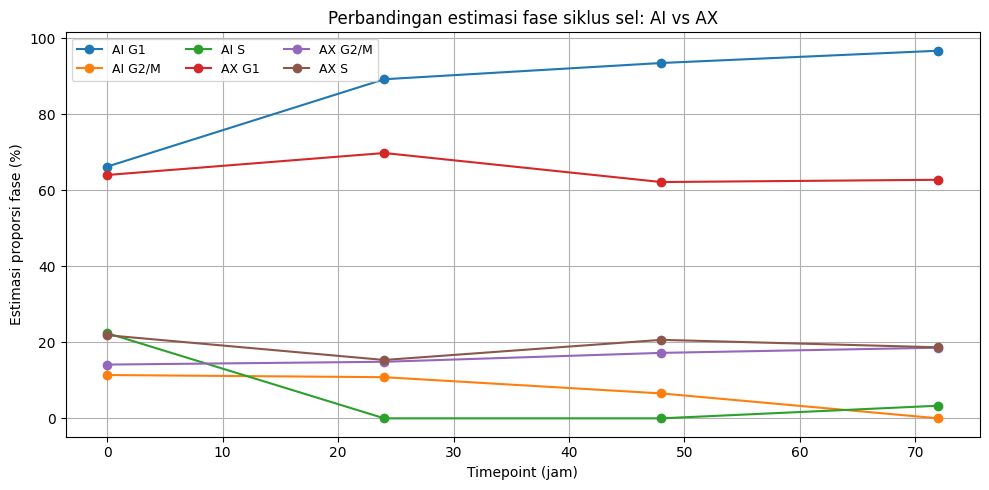

,condition,timepoint_hours,g1_percent,s_percent,g2_m_percent,r_squared,warnings
0,AI,0,66.201845,2.240460e+01,1.139355e+01,0.874278,
1,AI,24,89.177935,4.945817e-07,1.082206e+01,0.936929,
2,AI,48,93.450064,1.730550e-06,6.549934e+00,0.896694,
3,AI,72,96.679143,3.320857e+00,2.485717e-07,0.524899,R-squared rendah; interpretasi fase perlu hati...
4,AX,0,63.997184,2.186481e+01,1.413800e+01,0.856215,
5,AX,24,69.775265,1.534847e+01,1.487626e+01,0.868911,
6,AX,48,62.141130,2.064308e+01,1.721579e+01,0.903023,
7,AX,72,62.739937,1.867903e+01,1.858103e+01,0.885139,


In [8]:
phase_long = fit_df.melt(
    id_vars=["condition", "timepoint_hours"],
    value_vars=["g1_percent", "s_percent", "g2_m_percent"],
    var_name="phase",
    value_name="percent",
)
phase_long["phase"] = phase_long["phase"].map({
    "g1_percent": "G1",
    "s_percent": "S",
    "g2_m_percent": "G2/M",
})

fig, ax = plt.subplots(figsize=(10, 5))
for (condition, phase), group in phase_long.groupby(["condition", "phase"]):
    group = group.sort_values("timepoint_hours")
    ax.plot(group["timepoint_hours"], group["percent"], marker="o", label=f"{condition} {phase}")
ax.set_xlabel("Timepoint (jam)")
ax.set_ylabel("Estimasi proporsi fase (%)")
ax.set_title("Perbandingan estimasi fase siklus sel: AI vs AX")
ax.legend(ncol=3, fontsize=9)
fig.tight_layout()
plt.show()

fit_df[["condition", "timepoint_hours", "g1_percent", "s_percent", "g2_m_percent", "r_squared", "warnings"]]


## 7. Catatan Fase Berikutnya

- Pindahkan fungsi fitting ke module reusable pada fase 3 agar notebook dan backend memakai logic yang sama.
- Evaluasi gating PI-A lebih serius, terutama pembuangan debris dan doublet bila dibutuhkan.
- Gunakan residual, RMSE, dan R-squared untuk menentukan apakah fit cukup layak dibahas di laporan.
- Hindari klaim klinis; hasil adalah estimasi model untuk tugas komputasi biologi IF3211.